<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project4/pafolabi_DIAML_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data, Inference, and Applied Machine Learning - Assignment 4

In [1]:
#Importation of libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import scipy as scp
from scipy import stats

##Question 1

Dataset: [Monthly House Price Data](https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project4/data/Monthly.csv
)

In [2]:
#Data ingestion
house_url = 'https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project4/data/Monthly.csv'
ftse_url = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project4/data/FTSE100.csv'

house = pd.read_csv(house_url)
ftse = pd.read_csv(ftse_url)

#Clean the house price data
house['Date'] = pd.to_datetime(house['Mon-YY'], format='%b-%y')
house['HousePrice'] = house['Average House Price'].str.replace('[£,]', '', regex=True).astype(float)
ftse['Date'] = pd.to_datetime(ftse['Date'])

#Join on month and keep January 1991 to August 2026
df = house[['Date', 'HousePrice']].merge(ftse[['Date', 'Close']], on='Date').sort_values('Date')
df = df[(df['Date'] >= '1991-01-01') & (df['Date'] <= '2026-08-31')].reset_index(drop=True)
print(df.shape, df['Date'].min(), df['Date'].max())
df.head()

(428, 3) 1991-01-01 00:00:00 2026-08-01 00:00:00


,Date,HousePrice,Close
0,1991-01-01,53052.0,2170.300049
1,1991-02-01,53497.0,2380.899902
2,1991-03-01,52893.0,2456.500000
3,1991-04-01,53677.0,2486.199951
4,1991-05-01,54386.0,2499.500000


###(a) Fit a linear regression using the raw Average House Price level as the explanatory variable and the raw FTSE100 Close level as the dependent variable. Then compute the monthly return of each series as r(t) = p(t)/p(t−1) − 1, and fit the same regression using returns instead of levels. For both regressions, report the slope, intercept, correlation coefficient, R², and p-value

In [3]:
def fit(x, y):
    s = stats.linregress(x, y)
    return {'Slope': s.slope, 'Intercept': s.intercept, 'Correlation': s.rvalue, 'R squared': s.rvalue**2, 'p-value': s.pvalue}

#Levels
levels_res = fit(df['HousePrice'], df['Close'])

#Returns: r(t) = p(t)/p(t-1) - 1
df['HouseRet'] = df['HousePrice'] / df['HousePrice'].shift(1) - 1
df['FTSERet'] = df['Close'] / df['Close'].shift(1) - 1
ret = df.dropna().reset_index(drop=True)
returns_res = fit(ret['HouseRet'], ret['FTSERet'])

pd.DataFrame({'Levels': levels_res, 'Returns': returns_res})

,Levels,Returns
Slope,1.984993e-02,0.067812
Intercept,2.697443e+03,0.004257
Correlation,8.304780e-01,0.018603
R squared,6.896936e-01,0.000346
p-value,2.621893e-110,0.701484


**My answer to (a):** The table above shows both regressions. On levels, the slope is about 0.0198, the intercept is about 2697, the correlation is about 0.83, R² is about 0.69 and the p-value is far below 0.05. On returns, the slope is about 0.068, the intercept is about 0.0043, the correlation is about 0.019, R² is about 0.0003 and the p-value is about 0.70. So the levels look strongly linked, while the returns show almost nothing.

###(b) These two regressions give strikingly different answers. Explain why, by checking how much of each series's own variation is explained purely by the passage of time.

In [4]:
t_levels = np.arange(len(df))
t_returns = np.arange(len(ret))

time_res = pd.DataFrame({
    'House price level': fit(t_levels, df['HousePrice']),
    'FTSE100 level': fit(t_levels, df['Close']),
    'House price return': fit(t_returns, ret['HouseRet']),
    'FTSE100 return': fit(t_returns, ret['FTSERet']),
}).T
time_res[['Slope', 'R squared', 'p-value']]

,Slope,R squared,p-value
House price level,576.382333,0.958265,5.781094e-296
FTSE100 level,12.210298,0.752758,2.417255e-131
House price return,-0.000007,0.005787,1.165015e-01
FTSE100 return,-0.000009,0.000776,5.658223e-01


**My answer to (b):** Time alone explains about 96% of the variation in house price levels and about 75% of the variation in FTSE100 levels. Both series mostly just go up over the years, so they look related only because they trend together. That is a spurious regression. The high R² of 0.69 in the levels model comes from the shared upward trend and says little about a real link. Returns remove the trend. Time explains well under 1% of the variation in each return series (R² of about 0.006 and 0.0008). Once the trend is gone, the strong relationship disappears, which is why the two regressions give such different answers. I trust the returns regression more.

###(c) Interpret the slope, intercept, correlation, and R² from the returns-based regression. What does each one tell you about the relationship between house price returns and FTSE returns? Use a hypothesis test to back up your conclusion about whether a significant relationship exists.

In [5]:
#Test H0: slope = 0 against H1: slope != 0 at the 5% level
s = stats.linregress(ret['HouseRet'], ret['FTSERet'])
t_stat = s.slope / s.stderr
print('Slope:', s.slope, 'Std error:', s.stderr)
print('t statistic:', t_stat)
print('p-value:', s.pvalue)
print('Reject H0 at 5%?', s.pvalue < 0.05)

Slope: 0.06781163018403417 Std error: 0.17678787126305093
t statistic: 0.38357625836861897
p-value: 0.7014843456027526
Reject H0 at 5%? False


**My answer to (c):** The slope of about 0.068 means that when house prices rise 1 percentage point in a month, the FTSE100 return is only expected to be about 0.07 percentage points higher. That is tiny. The intercept of about 0.0043 means the FTSE100 is expected to return about 0.43% in a month when house prices do not change. The correlation of about 0.019 is very close to zero, so there is almost no straight line link. R² of about 0.0003 means house price returns explain only about 0.03% of the ups and downs in FTSE returns.

For the hypothesis test, the null hypothesis is that the slope is 0 (no relationship) and the alternative is that it is not 0. The p-value is about 0.70, which is much bigger than 0.05, so I fail to reject the null hypothesis. I do not find a significant relationship between monthly house price returns and FTSE100 returns.

###(d) Slope and correlation are not the same thing; explain what each one is actually telling you, and why a small regression slope can coexist with a strong correlation, and vice versa. Plot the return data points together with the fitted regression line, and discuss what the plot shows in light of your answer.

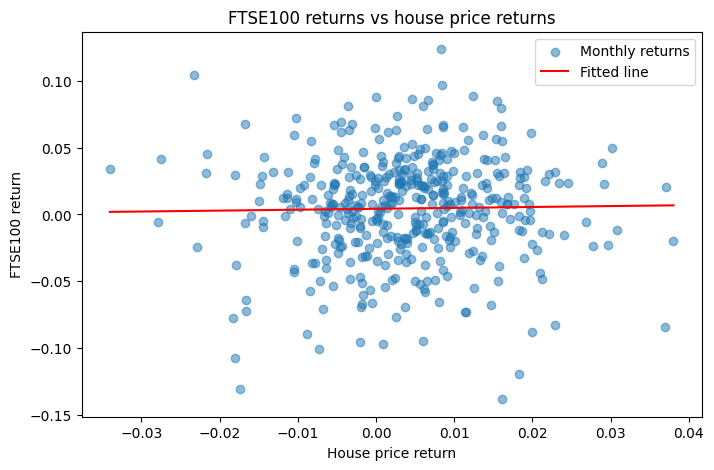

Std of house returns: 0.010598262217279737
Std of FTSE returns: 0.038632850464184076


In [6]:
x = ret['HouseRet']
plt.figure(figsize=(8, 5))
plt.scatter(x, ret['FTSERet'], alpha=0.5, label='Monthly returns')
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, returns_res['Intercept'] + returns_res['Slope'] * xs, color='red', label='Fitted line')
plt.xlabel('House price return')
plt.ylabel('FTSE100 return')
plt.title('FTSE100 returns vs house price returns')
plt.legend()
plt.show()

print('Std of house returns:', x.std())
print('Std of FTSE returns:', ret['FTSERet'].std())

**My answer to (d):** The slope tells me how many units y changes for a one unit change in x, so it depends on the units and spread of the two variables. The correlation tells me how tightly the points sit around a straight line, on a scale from -1 to 1, and it has no units. Because the slope equals the correlation times (std of y divided by std of x), a small slope can still come with a strong correlation if y moves very little compared with x. A big slope can come with a weak correlation if y has a lot of spread compared with x, and the points are scattered.

In my data, house returns have a std of about 0.011 and FTSE returns have a std of about 0.039, so FTSE is much more spread out. Even so, the slope is small and the correlation is near zero, so both agree that there is no real link. In the plot, the points form a round cloud with no clear direction. The red line is almost flat and the points are scattered far from it, mostly up and down. This matches the weak result I found in (c).

###(e) Choosing the dependent and explanatory variables in a regression does not establish causality; this model treats house-price returns as explaining FTSE returns. Does the data alone justify that direction, or could the roles of x and y just as easily be reversed? Rerun the regression with the two variables swapped and report the new slope, intercept, correlation, and R². Which of these changes, and which stays the same? And why?

In [7]:
swapped_res = fit(ret['FTSERet'], ret['HouseRet'])
pd.DataFrame({'House on FTSE (original)': returns_res, 'FTSE on House (swapped)': swapped_res})

,House on FTSE (original),FTSE on House (swapped)
Slope,0.067812,0.005103
Intercept,0.004257,0.003898
Correlation,0.018603,0.018603
R squared,0.000346,0.000346
p-value,0.701484,0.701484


**My answer to (e):** No, the data alone does not justify the direction. A regression only describes how two variables move together. It does not say which one causes the other. The roles could easily be reversed, and there could also be a third thing, like the economy or interest rates, that affects both.

After swapping, the slope changes from about 0.068 to about 0.0051 and the intercept changes from about 0.0043 to about 0.0039. The correlation (about 0.0186), R² (about 0.0003) and p-value (about 0.70) stay exactly the same. The correlation and R² do not depend on which variable is x or y. The slope and intercept do change because the slope is the correlation times the ratio of the standard deviations, and the ratio flips when the variables swap. The intercept changes because it depends on the slope and the means. This shows that the correlation is a symmetric measure while the regression line is not, and neither one proves causality.